## Objectif
L’objectif est de segmenter automatiquement différentes classes vestimentaires et corporelles
(chapeau, cheveux, haut, pantalon, robe, bras, jambes, chaussures, sac, etc.)
à partir d’images en entrée.

## Méthodologie
Le traitement suit les étapes suivantes :
1. chargement des images ;
2. envoi à l’API du modèle SegFormer hébergé sur Hugging Face ;
3. décodage des masques renvoyés ;
4. fusion des classes de chaussures ;
5. construction d’un masque final ;
6. visualisation des résultats.

In [1]:
import os
import io
import base64
import mimetypes
import requests
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from dotenv import load_dotenv
from matplotlib.patches import Patch
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [2]:
# Dossier contenant les images à segmenter
image_dir = "i:/OC/P2/projet2/src/projet2/content/images/IMG"

# Nombre maximum d'images à traiter
max_images = 4

# Nombre d'images affichées par fenêtre
images_per_window = 2

# URL du modèle de segmentation
API_URL = "https://router.huggingface.co/hf-inference/models/sayeed99/segformer_b3_clothes"

In [3]:
# Chargement du token Hugging Face depuis le fichier .env
load_dotenv()
api_token = os.getenv("HF_API_TOKEN")

if not api_token:
    raise ValueError("HF_API_TOKEN introuvable. Ajoutez-le dans le fichier .env.")

print("Dossier courant =", os.getcwd())

# Vérifie si le dossier d'images existe
if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Dossier '{image_dir}' créé. Veuillez y ajouter des images .jpg ou .png.")
else:
    print(f"Dossier '{image_dir}' existant.")

Dossier courant = i:\OC\P2\projet2\src\projet2
Dossier 'i:/OC/P2/projet2/src/projet2/content/images/IMG' existant.


In [4]:
# Extensions acceptées
extensions_valides = (".jpg", ".jpeg", ".png", ".webp")

# Liste des images à traiter
image_paths = [
    os.path.join(image_dir, f)
    for f in os.listdir(image_dir)
    if f.lower().endswith(extensions_valides)
][:max_images]

if not image_paths:
    print(f"Aucune image trouvée dans '{image_dir}'. Veuillez y ajouter des images.")
else:
    print(f"{len(image_paths)} image(s) à traiter :")
    for path in image_paths:
        print("-", path)

4 image(s) à traiter :
- i:/OC/P2/projet2/src/projet2/content/images/IMG\image_0.png
- i:/OC/P2/projet2/src/projet2/content/images/IMG\image_1.png
- i:/OC/P2/projet2/src/projet2/content/images/IMG\image_10.png
- i:/OC/P2/projet2/src/projet2/content/images/IMG\image_11.png


In [5]:
# Correspondance nom de classe -> identifiant numérique brut du modèle
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Dress": 7,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

# Classe fusionnée pour les chaussures
SHOES_CLASS_ID = 9

In [6]:
# Libellés finaux réellement affichés
CLASS_NAMES_FR = {
    0: "Arrière-plan",
    1: "Chapeau",
    2: "Cheveux",
    3: "Lunettes de soleil",
    4: "Haut (vêtement)",
    5: "Jupe",
    6: "Pantalon",
    7: "Robe",
    8: "Ceinture",
    9: "Chaussures",
    11: "Visage",
    12: "Jambe gauche",
    13: "Jambe droite",
    14: "Bras gauche",
    15: "Bras droit",
    16: "Sac",
    17: "Écharpe"
}

In [7]:
# Même couleur pour les zones de peau
SKIN_COLOR = (176, 196, 222)

# Palette finale
CLASS_COLORS = {
    0: (0, 0, 0),           # Arrière-plan = noir
    1: (255, 255, 0),       # Chapeau = jaune
    2: (255, 165, 0),       # Cheveux = orange
    3: (255, 0, 255),       # Lunettes = magenta
    4: (255, 0, 0),         # Haut = rouge
    5: (255, 192, 203),     # Jupe = rose clair
    6: (0, 255, 0),         # Pantalon = vert
    7: (128, 0, 128),       # Robe = violet
    8: (0, 255, 255),       # Ceinture = cyan
    9: (255, 255, 0),       # Chaussures = jaune
    11: SKIN_COLOR,         # Visage
    12: SKIN_COLOR,         # Jambe gauche
    13: SKIN_COLOR,         # Jambe droite
    14: SKIN_COLOR,         # Bras gauche
    15: SKIN_COLOR,         # Bras droit
    16: (255, 140, 0),      # Sac = orange foncé
    17: (138, 43, 226)      # Écharpe = violet bleuté
}

In [8]:
def normalize_class_id(class_id):
    """
    Fusionne Left-shoe (9) et Right-shoe (10)
    en une seule classe : Chaussures (9).
    """
    if class_id in (9, 10):
        return SHOES_CLASS_ID
    return class_id


def get_image_dimensions(img_path):
    """
    Ouvre l'image et retourne ses dimensions (largeur, hauteur).
    """
    with Image.open(img_path) as original_image:
        return original_image.size


def decode_base64_mask(base64_string, width, height):
    """
    Décode un masque base64 et le redimensionne
    à la taille de l'image d'origine.
    """
    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)

    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0]

    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

In [9]:
def create_masks(results, width, height):
    """
    Construit un masque final robuste à partir des résultats de l'API.

    Stratégie :
    - décodage de tous les masques,
    - utilisation du score si disponible,
    - résolution des conflits par score puis priorité.
    """
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    score_map = np.full((height, width), -1.0, dtype=np.float32)

    class_priority = {
        9: 100,   # Chaussures
        16: 80,   # Sac
        8: 70,    # Ceinture
        4: 60,    # Haut
        5: 60,    # Jupe
        6: 60,    # Pantalon
        7: 60,    # Robe
        14: 50,   # Bras gauche
        15: 50,   # Bras droit
        12: 50,   # Jambe gauche
        13: 50,   # Jambe droite
        11: 50,   # Visage
        1: 40,    # Chapeau
        2: 40,    # Cheveux
        3: 40,    # Lunettes
        17: 40,   # Écharpe
        0: 0
    }

    decoded_items = []

    for result in results:
        label = result["label"]
        raw_class_id = CLASS_MAPPING.get(label, 0)
        class_id = normalize_class_id(raw_class_id)

        mask_array = decode_base64_mask(result["mask"], width, height)
        score = float(result.get("score", 1.0))

        decoded_items.append({
            "class_id": class_id,
            "mask": mask_array > 0,
            "score": score,
            "priority": class_priority.get(class_id, 1)
        })

    foreground_items = [item for item in decoded_items if item["class_id"] != 0]

    foreground_items.sort(
        key=lambda x: (x["score"], x["priority"]),
        reverse=True
    )

    current_priority_map = np.zeros((height, width), dtype=np.int16)

    for item in foreground_items:
        class_id = item["class_id"]
        mask_bool = item["mask"]
        score = item["score"]
        priority = item["priority"]

        replace_better_score = mask_bool & (score > score_map)

        replace_equal_score = (
            mask_bool
            & np.isclose(score, score_map)
            & (priority > current_priority_map)
        )

        replace = replace_better_score | replace_equal_score

        combined_mask[replace] = class_id
        score_map[replace] = score
        current_priority_map[replace] = priority

    return combined_mask

In [10]:
def colorize_mask(final_mask):
    """
    Convertit le masque final en image RGB selon la palette définie.
    """
    height, width = final_mask.shape
    color_mask = np.zeros((height, width, 3), dtype=np.uint8)

    for class_id, color in CLASS_COLORS.items():
        color_mask[final_mask == class_id] = color

    return color_mask


def overlay_mask_on_image(original_image, color_mask, alpha=0.45):
    """
    Superpose le masque coloré sur l'image d'origine.
    """
    original_np = np.array(original_image).astype(np.float32)
    color_np = color_mask.astype(np.float32)

    overlay = (1 - alpha) * original_np + alpha * color_np
    return np.clip(overlay, 0, 255).astype(np.uint8)

In [11]:
def build_legend_handles():
    """
    Construit les éléments de légende sans doublons.
    """
    handles = []

    for class_id in sorted(CLASS_NAMES_FR.keys()):
        color_rgb = np.array(CLASS_COLORS[class_id]) / 255.0
        label = CLASS_NAMES_FR[class_id]

        handles.append(
            Patch(
                facecolor=color_rgb,
                edgecolor="none",
                label=label
            )
        )

    return handles


def add_legend_to_axis(ax, fontsize=8):
    """
    Ajoute une légende verticale à droite d'un axe.
    """
    legend_handles = build_legend_handles()

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        fontsize=fontsize,
        borderaxespad=0.0,
        labelspacing=0.25,
        handlelength=1.0,
        handleheight=1.0,
        handletextpad=0.4
    )

In [12]:
def segment_images_batch(list_of_image_paths):
    """
    Segmente plusieurs images en batch.

    Retour :
    - liste de dictionnaires contenant :
        - image_path
        - mask
    """
    batch_segmentations = []

    retry_strategy = Retry(
        total=5,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["POST"]),
        raise_on_status=False,
        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)

    with requests.Session() as session:
        session.mount("https://", adapter)
        session.headers.update({
            "Authorization": f"Bearer {api_token}",
            "Accept": "application/json"
        })

        for image_path in tqdm(list_of_image_paths, desc="Segmentation en cours"):
            try:
                print(f"\nTraitement de l'image : {image_path}")

                with open(image_path, "rb") as f:
                    image_data = f.read()

                content_type, _ = mimetypes.guess_type(image_path)
                if content_type is None:
                    raise ValueError(f"Impossible de déterminer le type MIME pour {image_path}")

                response = session.post(
                    API_URL,
                    headers={"Content-Type": content_type},
                    data=image_data,
                    timeout=(10, 90)
                )

                response.raise_for_status()
                result = response.json()

                width, height = get_image_dimensions(image_path)
                final_mask = create_masks(result, width, height)

                print("Classes présentes :", np.unique(final_mask))

                batch_segmentations.append({
                    "image_path": image_path,
                    "mask": final_mask
                })

            except Exception as e:
                print(f"Une erreur est survenue pour {image_path} : {e}")
                batch_segmentations.append({
                    "image_path": image_path,
                    "mask": None
                })

    return batch_segmentations

In [13]:
def display_results_paginated(batch_seg_results, images_per_window=2):
    """
    Affiche les résultats par groupes d'images.

    Chaque image est affichée sur une ligne avec 3 colonnes :
    - image originale
    - masque segmenté
    - image + segmentation
    """
    valid_results = [item for item in batch_seg_results if item["mask"] is not None]

    if not valid_results:
        print("Aucun résultat valide à afficher.")
        return

    total_images = len(valid_results)

    for start_idx in range(0, total_images, images_per_window):
        end_idx = min(start_idx + images_per_window, total_images)
        chunk = valid_results[start_idx:end_idx]
        n = len(chunk)

        fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(22, 6 * n))

        if n == 1:
            axes = np.array([axes])

        for i, item in enumerate(chunk):
            original_image = Image.open(item["image_path"]).convert("RGB")
            final_mask = item["mask"]

            color_mask = colorize_mask(final_mask)
            overlay_image = overlay_mask_on_image(original_image, color_mask, alpha=0.45)

            image_number = start_idx + i + 1
            file_name = os.path.basename(item["image_path"])

            # Colonne 1 : image originale
            axes[i, 0].imshow(original_image)
            axes[i, 0].set_title(
                f"Image {image_number} - Originale\n{file_name}",
                fontsize=10
            )
            axes[i, 0].axis("off")

            # Colonne 2 : masque segmenté
            axes[i, 1].imshow(color_mask)
            axes[i, 1].set_title(
                f"Image {image_number} - Masque segmenté",
                fontsize=10
            )
            axes[i, 1].axis("off")
            add_legend_to_axis(axes[i, 1], fontsize=8)

            # Colonne 3 : superposition
            axes[i, 2].imshow(overlay_image)
            axes[i, 2].set_title(
                f"Image {image_number} - Image + segmentation",
                fontsize=10
            )
            axes[i, 2].axis("off")
            add_legend_to_axis(axes[i, 2], fontsize=8)

        fig.suptitle(
            f"Résultats de segmentation - Images {start_idx + 1} à {end_idx}",
            fontsize=14
        )

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

In [14]:
if image_paths:
    print(f"\nTraitement de {len(image_paths)} image(s) en batch...")
    batch_seg_results = segment_images_batch(image_paths)
    print("Traitement en batch terminé.")
else:
    batch_seg_results = []
    print("Aucune image à traiter en batch.")


Traitement de 4 image(s) en batch...


Segmentation en cours:   0%|          | 0/4 [00:00<?, ?it/s]


Traitement de l'image : i:/OC/P2/projet2/src/projet2/content/images/IMG\image_0.png


Segmentation en cours:  25%|██▌       | 1/4 [00:38<01:54, 38.20s/it]

Classes présentes : [ 0  2  4  6  9 11 12 13 15 16]

Traitement de l'image : i:/OC/P2/projet2/src/projet2/content/images/IMG\image_1.png


...

Classes présentes : [ 0  1  2  4  5  6  9 11 15 16]

Traitement de l'image : i:/OC/P2/projet2/src/projet2/content/images/IMG\image_10.png


Segmentation en cours:  75%|███████▌  | 3/4 [01:16<00:23, 23.09s/it]

Classes présentes : [ 0  2  4  5  8  9 11 12 13 14 15 16]

Traitement de l'image : i:/OC/P2/projet2/src/projet2/content/images/IMG\image_11.png


Segmentation en cours: 100%|██████████| 4/4 [01:23<00:00, 20.99s/it]

Classes présentes : [ 0  1  2  4  5  6  9 11 12 13 14]
Traitement en batch terminé.


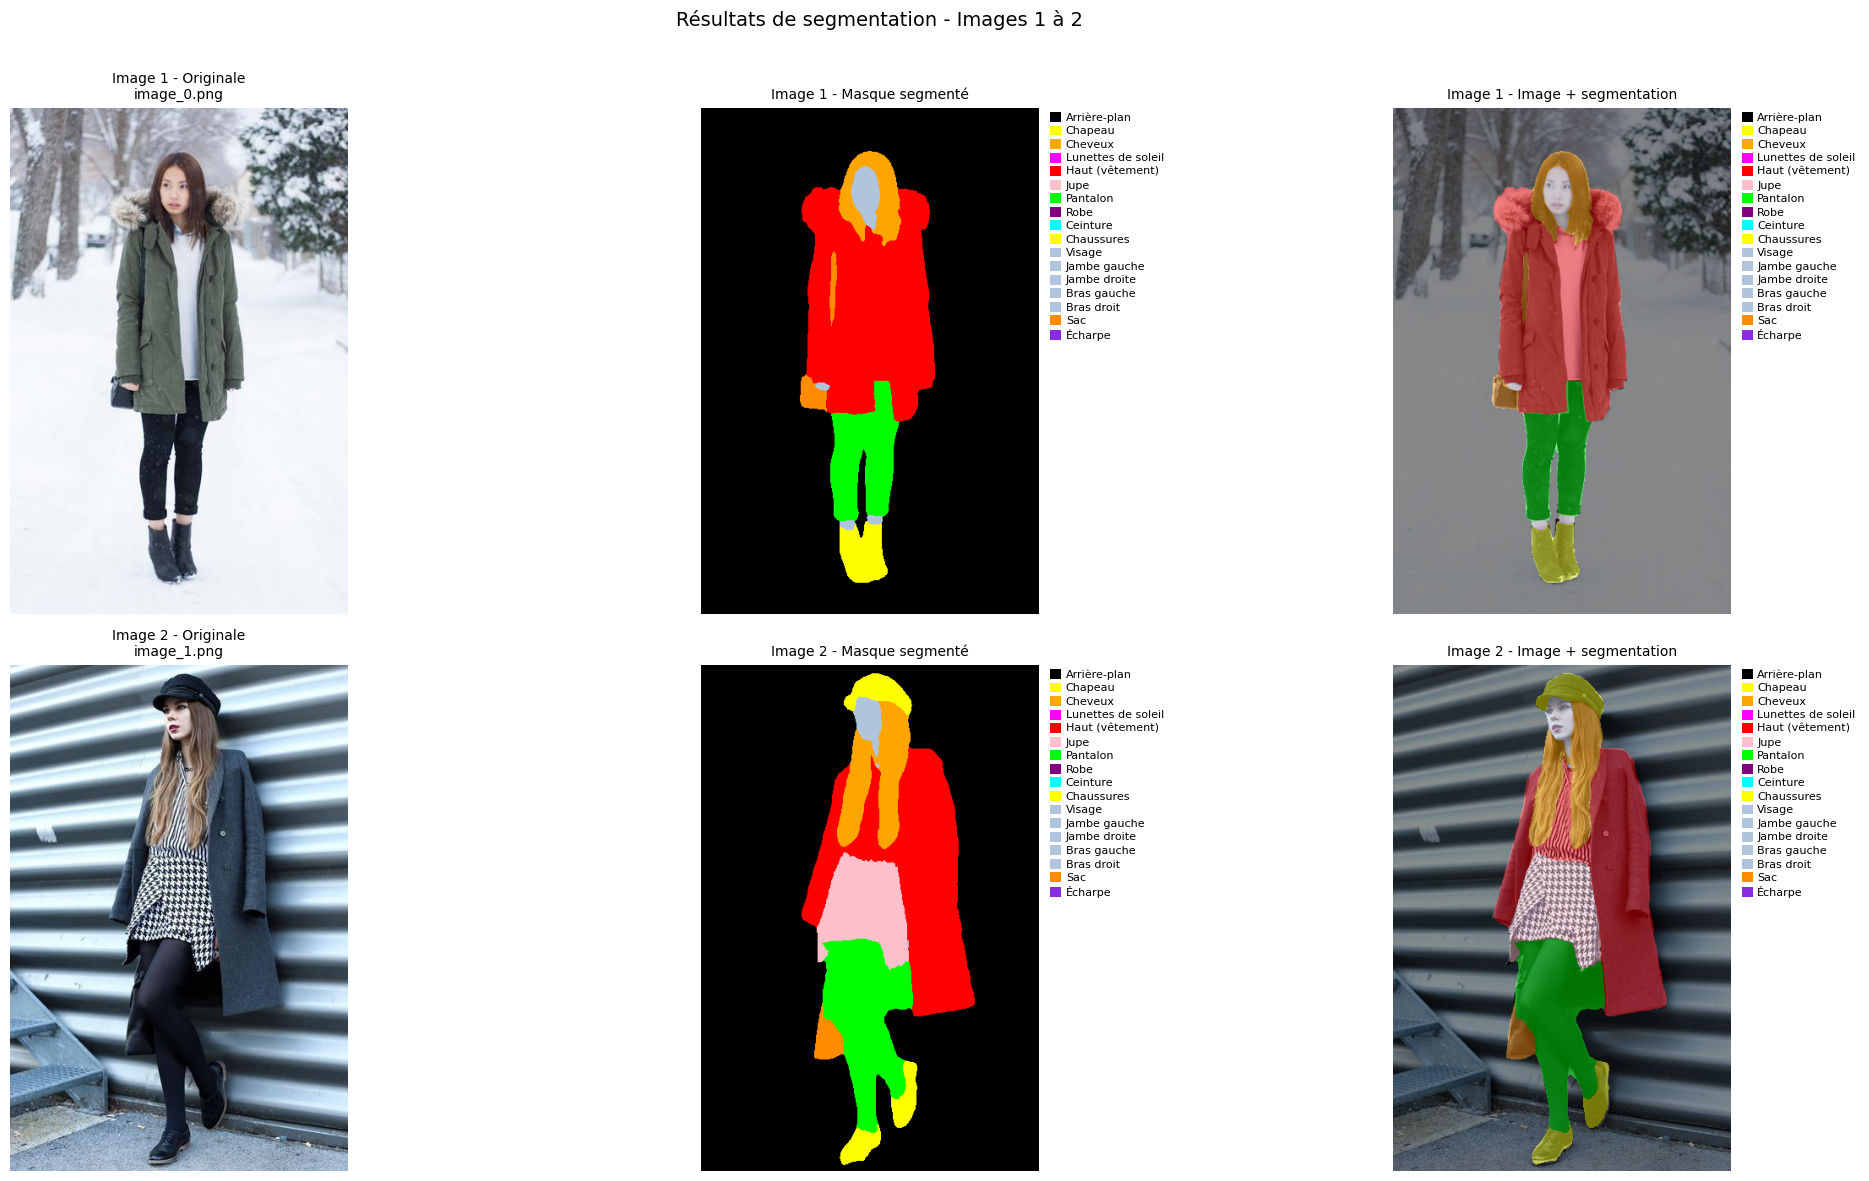

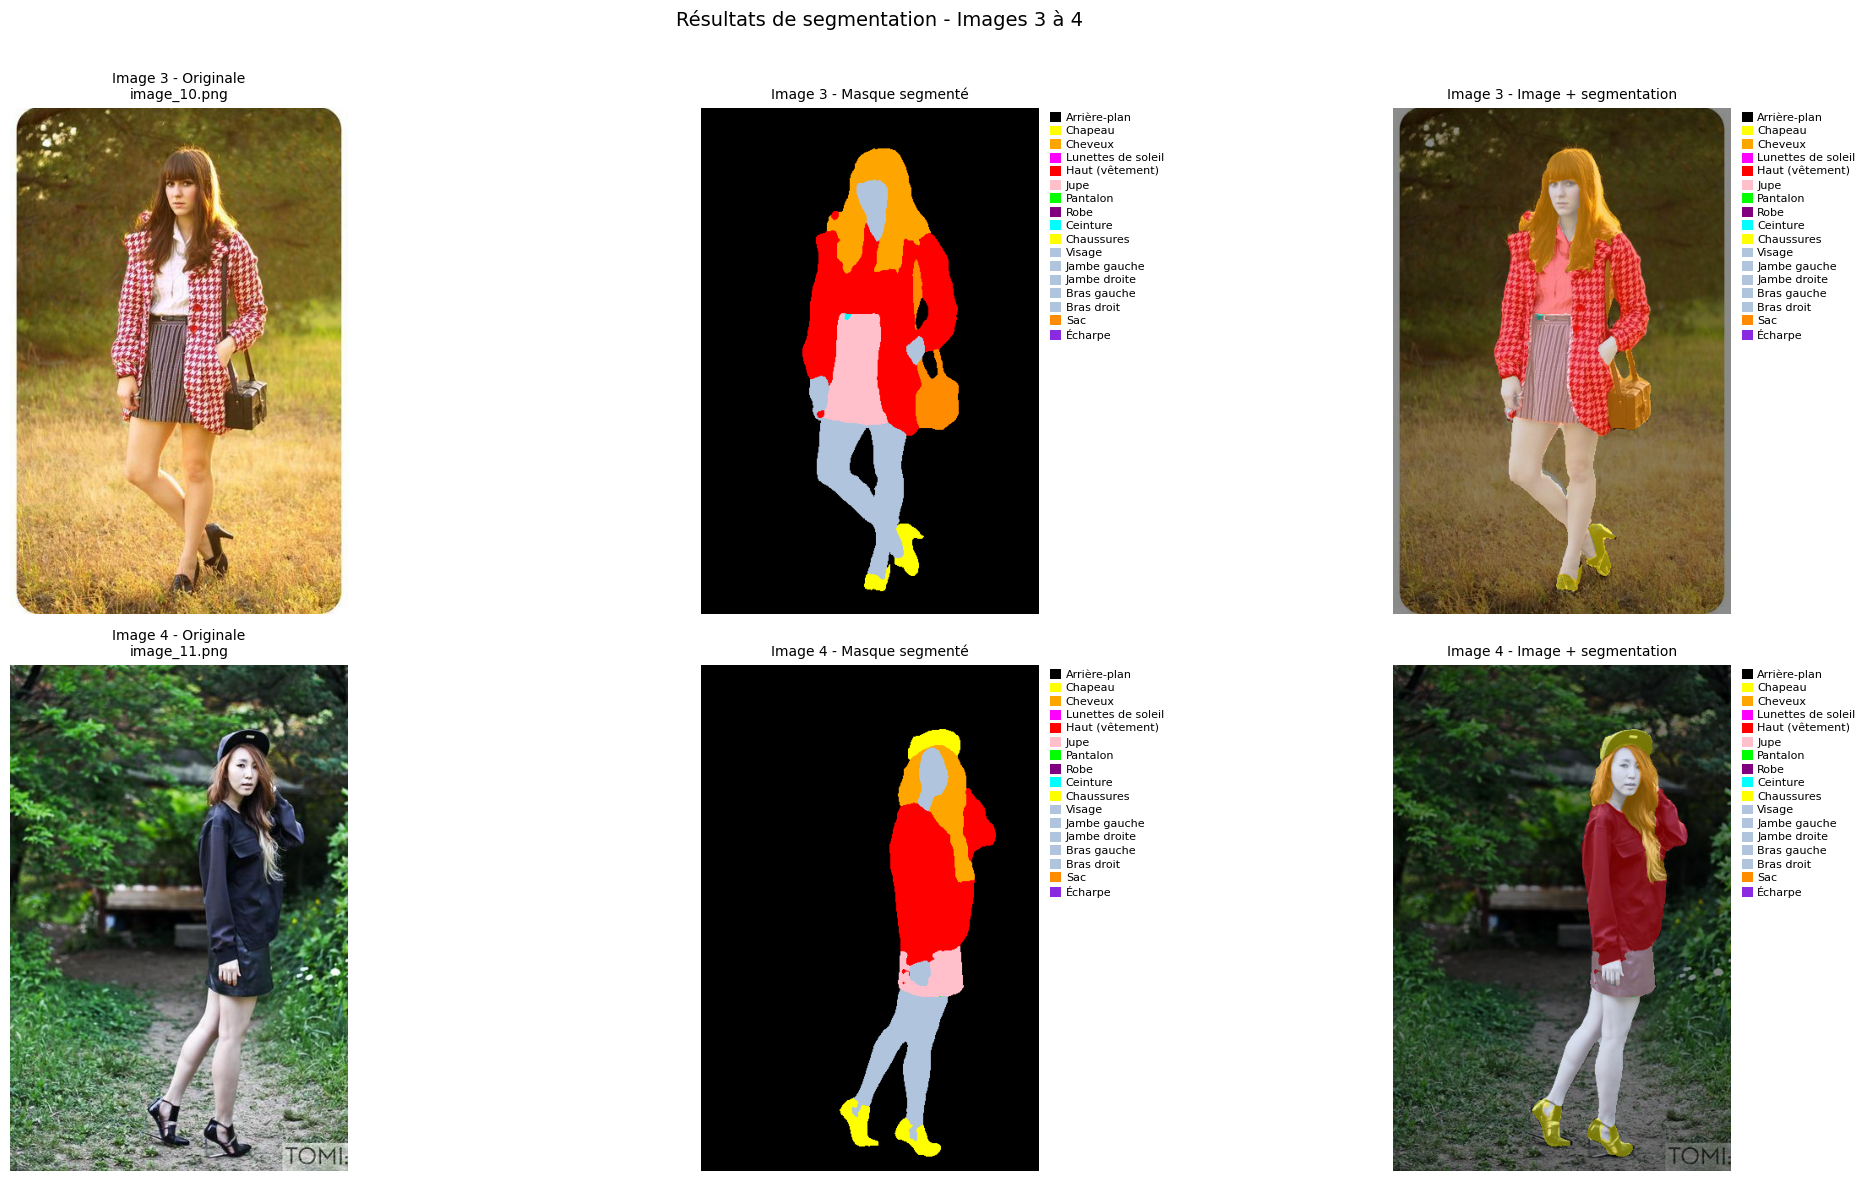

In [15]:
display_results_paginated(batch_seg_results, images_per_window=images_per_window)